<a href="https://colab.research.google.com/github/Jorgemontanez25/PGP-AIML-BA-UTA-Jan25-B/blob/main/HelmNet_Full_Code_Jorge_Montanez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import google.protobuf

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Protobuf:", google.protobuf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.18.0
NumPy: 2.0.2
Protobuf: 5.29.5
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from typing import Union, Dict



# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/Data, AI and Machine Learning UT/Project 6: Introduction to Computer Vision : HelmNet/images_proj.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/Data, AI and Machine Learning UT/Project 6: Introduction to Computer Vision : HelmNet/Labels_proj.csv')

# **Exploratory Data Analysis**

###Let's check the shape of the images and labels

In [ ]:
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


###Observations
There are 631 RGB  images of shape 200 x 200 X 3, each image having 3 channels.

###Plot random images from each of the classes and print their corresponding labels.

In [ ]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

In [ ]:
def show_random_images(images: np.ndarray, labels: pd.DataFrame, label_names: dict[int, str], n_per_class: int = 5):
    for label_val, class_name in label_names.items():
        # Get indices for current class
        idx = labels[labels.iloc[:, 0] == label_val].index.tolist()
        selected = random.sample(idx, n_per_class)

        # Plot
        plt.figure(figsize=(n_per_class * 2, 2.5))
        for i, img_idx in enumerate(selected):
            plt.subplot(1, n_per_class, i + 1)
            plt.imshow(images[img_idx].astype(np.uint8))
            plt.title(class_name)
            plt.axis('off')
        plt.tight_layout()
        plt.show()


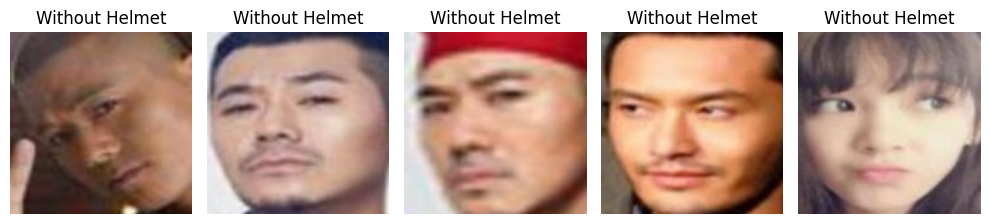

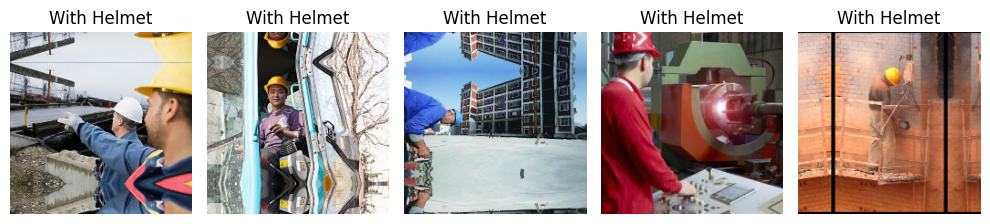

In [ ]:
label_names = {
    0: "Without Helmet",
    1: "With Helmet"
}

show_random_images(images, labels, label_names, n_per_class=5)


###Observations:
Images are converted from BGR to RGB using OpenCV, which is essential since OpenCV loads images in BGR format, while Matplotlib expects RGB. Five randomly selected images per class are displayed, allowing for visual inspection of class distribution and label consistency. Additionally, the images are cast to np.uint8, ensuring compatibility with imshow and preventing overflow or format-related issues.
However, there appears to be noticeable homogeneity among the samples — such as face-centric cropping, similar backgrounds, and consistent lighting conditions. This uniformity could lead the model to overfit to superficial features (like background color or facial alignment) rather than learning the true semantic distinction (e.g., the presence or absence of a helmet).

## Checking for class imbalance


Class Distribution:
 Label
With Helmet       311
Without Helmet    320
Name: count, dtype: int64


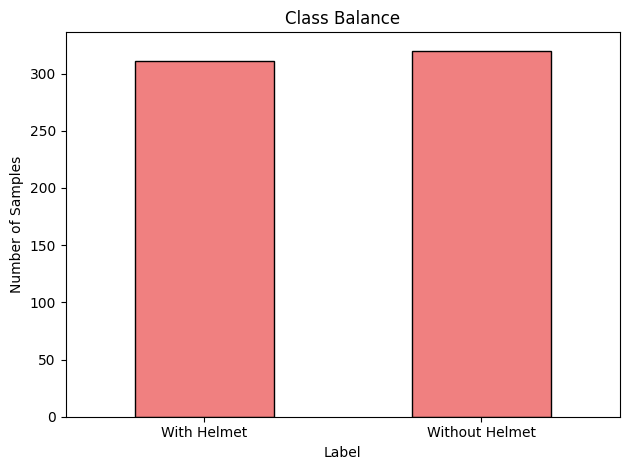

In [ ]:
# Flatten labels and map to names
label_series = labels.iloc[:, 0].map(label_names)

# Count class occurrences
counts = label_series.value_counts().sort_index()

# Print
print("Class Distribution:\n", counts)

# Plot
counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Class Balance")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


###Obsercations:
The dataset demonstrates a well-balanced distribution between the two classes, with 311 images labeled "With Helmet" and 320 labeled "Without Helmet." This near-equal representation helps prevent the model from developing a biased decision boundary that favors one class over the other. As a result, there is no immediate need to apply class rebalancing techniques such as oversampling, undersampling, or adjusting class weights, making the dataset naturally suitable for training a fair binary classifier.


# **Data Preprocessing**

## Converting images to grayscale

In [ ]:
def convert_to_grayscale(images: np.ndarray) -> np.ndarray:
    """
    Convert an array of RGB images to grayscale.

    Args:
        images (np.ndarray): Array of images in RGB format with shape (N, H, W, 3)

    Returns:
        np.ndarray: Array of grayscale images with shape (N, H, W)
    """
    gray_images = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images])
    return gray_images




In [ ]:
def show_grayscale_examples(images: np.ndarray, labels, label_names: dict, n: int = 5) -> None:
    """
    Display random grayscale images with class labels.

    Args:
        images (np.ndarray): Grayscale images of shape (N, H, W)
        labels (pd.DataFrame or np.ndarray): Corresponding labels
        label_names (dict): Mapping from label values to readable names
        n (int): Number of images to show
    """
    indices = random.sample(range(len(images)), n)
    plt.figure(figsize=(n * 2.5, 3))

    for i, idx in enumerate(indices):
        img = images[idx]
        label_val = labels.iloc[idx, 0] if hasattr(labels, "iloc") else labels[idx]
        label_str = label_names.get(label_val, str(label_val))

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(label_str)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


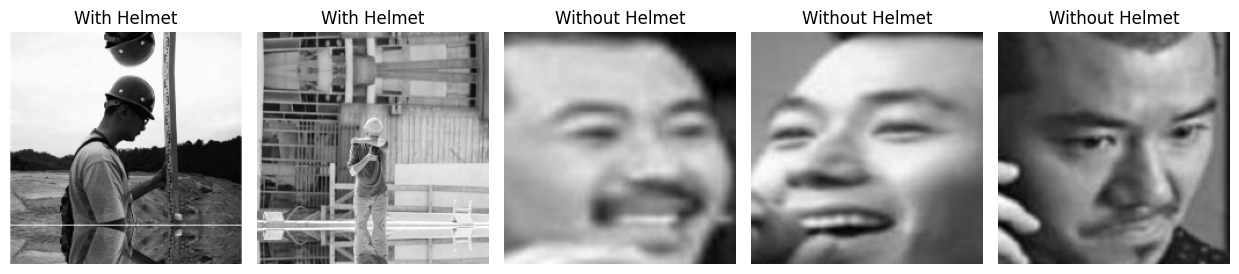

In [ ]:
label_names = {
    0: "Without Helmet",
    1: "With Helmet"
}

gray_images = convert_to_grayscale(images)  # Convert RGB images to grayscale

# ✅ This will DISPLAY 5 grayscale images with titles
show_grayscale_examples(gray_images, labels, label_names, n=5)



###Observations
Converting RGB images to grayscale reduces the data to intensity-only information, making it ideal for tasks focused on texture, shape, and edges—like helmet detection—while still preserving key visual features such as outlines and contrasts.

### Splitting the dataset



In [ ]:
gray_images_cnn = np.expand_dims(gray_images, axis=-1)  # Shape: (N, H, W, 1)


In [ ]:
gray_images_vgg = np.stack((gray_images,) * 3, axis=-1)  # Shape: (N, H, W, 3)


In [ ]:
# === For CNN Models ===
X_train_cnn, X_temp_cnn, y_train, y_temp = train_test_split(
    gray_images_cnn, labels, test_size=0.2, random_state=42, stratify=labels
)
X_val_cnn, X_test_cnn, y_val, y_test = train_test_split(
    X_temp_cnn, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
# 🟢 Keep original VGG images for visualization
X_val_original_cnn = X_val_cnn.copy()

# === For VGG16 Models ===
X_train_vgg, X_temp_vgg, _, _ = train_test_split(
    gray_images_vgg, labels, test_size=0.2, random_state=42, stratify=labels
)
X_val_vgg, X_test_vgg, _, _ = train_test_split(
    X_temp_vgg, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
# 🟢 Keep original VGG images for visualization
X_val_original_vgg = X_val_vgg.copy()

In [ ]:
# Save the original RGB images
original_rgb_images = np.array(images)

# First split to get train/temp
X_train_rgb, X_temp_rgb, _, _ = train_test_split(
    original_rgb_images, labels, test_size=0.2, random_state=42, stratify=labels
)

# Then split temp into val/test
X_val_rgb, X_test_rgb, _, _ = train_test_split(
    X_temp_rgb, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [ ]:
print("📦 CNN-compatible shapes:")
print(X_train_cnn.shape, y_train.shape)
print(X_val_cnn.shape, y_val.shape)
print(X_test_cnn.shape, y_test.shape)

print("\n📦 VGG-compatible shapes:")
print(X_train_vgg.shape, y_train.shape)
print(X_val_vgg.shape, y_val.shape)
print(X_test_vgg.shape, y_test.shape)

📦 CNN-compatible shapes:
(504, 200, 200, 1) (504, 1)
(63, 200, 200, 1) (63, 1)
(64, 200, 200, 1) (64, 1)

📦 VGG-compatible shapes:
(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


###Observations
The dataset is split and preprocessed into three separate formats: grayscale for custom CNNs, 3-channel grayscale for VGG16, and RGB for visualization. This modular setup makes it easy to train different models in parallel.

Grayscale images are reshaped for CNNs with one channel, while VGG16 images are stacked into three channels to match its input requirements. Stratified splitting ensures both classes are balanced across training, validation, and test sets, following a typical 80/10/10 ratio. Original validation images are saved separately to preserve them for visualization.

### Data Normalization

In [ ]:
# Normalizing the image pixels
X_train_cnn_normalized = X_train_cnn.astype("float32") / 255.0
X_val_cnn_normalized   = X_val_cnn.astype("float32") / 255.0
X_test_cnn_normalized  = X_test_cnn.astype("float32") / 255.0

X_train_vgg_normalized = X_train_vgg.astype("float32") / 255.0
X_val_vgg_normalized   = X_val_vgg.astype("float32") / 255.0
X_test_vgg_normalized  = X_test_vgg.astype("float32") / 255.0

# ✅ Normalize the original RGB images
X_train_rgb_normalized = X_train_rgb.astype("float32") / 255.0
X_val_rgb_normalized   = X_val_rgb.astype("float32") / 255.0
X_test_rgb_normalized  = X_test_rgb.astype("float32") / 255.0

###Observations
The dataset has been normalized by dividing all pixel values by 255.0, converting them from the range 0–255 to 0.0–1.0. This is a standard step that helps models train faster and more reliably. The data is also converted to 32-bit floats to match the expected format for deep learning models. Normalization is done separately for grayscale CNN images, RGB VGG16 images, and the original RGB images used for visualization. This keeps the data pipelines clean and ensures each model gets the right input format without mixing them up.

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
def to_1d_array(y):
    """Ensure the target is a 1D NumPy array."""
    if isinstance(y, pd.DataFrame):
        # If it's a DataFrame with one column
        return y.iloc[:, 0].values.ravel()
    elif isinstance(y, pd.Series):
        return y.values.ravel()
    return np.ravel(y)  # fallback for NumPy arrays


In [ ]:
y_train = to_1d_array(y_train)
y_val = to_1d_array(y_val)


In [ ]:
def model_performance_classification(
    model,
    X: np.ndarray,
    y: np.ndarray,
    binary: bool = True
) -> dict:
    """
    Evaluates a classification model and returns performance metrics.

    Args:
        model: Trained model.
        X (np.ndarray): Features.
        y (np.ndarray): True labels.
        binary (bool): Whether it is binary classification.

    Returns:
        dict: Dictionary of accuracy, precision, recall, and F1-score.
    """
    import numpy as np
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    # Predict probabilities
    pred_probs = model.predict(X)

    # Handle binary classification
    if binary:
        if pred_probs.shape[-1] == 1:
            preds = (pred_probs > 0.5).astype("int32").flatten()
        else:
            preds = np.argmax(pred_probs, axis=1)
    else:
        preds = np.argmax(pred_probs, axis=1)

    # Ensure labels are 1D arrays
    y_true = y.ravel()
    preds = preds.ravel()

    # Compute metrics
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1_score": f1_score(y_true, preds, zero_division=0)
    }




In [ ]:
def plot_confusion_matrix(model, predictors, target, title="Confusion Matrix", class_names=None):
    """Plots a confusion matrix for binary classification."""
    # Predict probabilities and convert to binary
    pred_probs = model.predict(predictors).flatten()
    pred = (pred_probs > 0.5).astype(int)

    # Convert true labels if needed
    if hasattr(target, "to_numpy"):
        target = target.to_numpy().flatten()

    cm = confusion_matrix(target, pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names else ["Pred 0", "Pred 1"],
        yticklabels=class_names if class_names else ["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()



In [ ]:
def reset_tf_session():
    """Clear TF session and reset memory (safe to call before every model)."""
    from tensorflow.keras import backend as K
    import gc
    import tensorflow as tf

    K.clear_session()
    gc.collect()
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)


###Observations:

These functions improve clarity, maintainability, and reusability across the machine learning pipeline.

*   to_1d_array(y): Ensures label arrays are consistently 1D across formats (DataFrame, Series, NumPy array), avoiding shape mismatches during training or metric computation.
*   reset_tf_session(): Clears TensorFlow sessions and memory (including GPU usage). Essential for avoiding memory leaks or OOM errors when training multiple models in the same notebook session.
*   model_performance_classification(): Computes and returns key classification metrics: accuracy, precision, recall, and F1-score. Handles both binary and multi-class classification seamlessly. Helps in consistent and structured evaluation of all model variants.
*   plot_confusion_matrix(...): Visualizes model predictions using a heatmap. Converts predictions to binary labels, aligns true labels, and supports optional custom class names. A valuable tool for spotting class-specific performance issues.



##Model 1: Simple Convolutional Neural Network (CNN)

In [ ]:
reset_tf_session()

In [ ]:
cnn_model = Sequential()
cnn_model.add(Conv2D(64, (3,3), activation='relu', input_shape=(200, 200, 1), padding='same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(16, (3,3), activation='relu', padding = 'same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

###Observations:
The CNN model follows a sequential design and is structured into five convolutional blocks. As the network progresses, these blocks increase in depth while reducing the spatial dimensions of the feature maps. Each block includes a ReLU activation function, same padding to preserve dimensions, MaxPooling2D for downsampling, and BatchNormalization to stabilize training. Once feature extraction is complete, the output is flattened and passed through three fully connected (Dense) layers. The final layer uses a sigmoid activation function, making it suitable for binary classification tasks. To help prevent overfitting, dropout layers with a rate of 0.25 are applied throughout the network.

In [ ]:
cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,593 (2.58 MB)

 Trainable params: 676,401 (2.58 MB)

 Non-trainable params: 192 (768.00 B)

###Observations:
The total parameter count is 676,593, which is moderate and suitable for experimentation on this dataset size.
The majority of parameters reside in the first dense layer after flattening (640,064), suggesting that most learning capacity lies in the fully connected part.

In [ ]:
model_history = cnn_model.fit(
    X_train_cnn_normalized, y_train,
    validation_data=(X_val_cnn_normalized, y_val),
    epochs=10
)



Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 583ms/step - accuracy: 0.6568 - loss: 0.5667 - val_accuracy: 0.5556 - val_loss: 0.6608
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9687 - loss: 0.0933 - val_accuracy: 0.5079 - val_loss: 0.7439
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9741 - loss: 0.0664 - val_accuracy: 0.5079 - val_loss: 0.7607
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9818 - loss: 0.0444 - val_accuracy: 0.8254 - val_loss: 0.3791
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9919 - loss: 0.0580 - val_accuracy: 0.5079 - val_loss: 1.6918
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9832 - loss: 0.0395 - val_accuracy: 0.5397 - val_loss: 0.8668
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9961 - loss: 0.0296 - val_accuracy: 0.5079 - val_loss: 1.6949
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9995 - loss: 0.0077 - val_accuracy: 0.5079 -

###Observations:
Training accuracy improves rapidly and reaches 100% by epoch 9.
Validation accuracy fluctuates significantly  and peaks only at 88.9%, with final validation accuracy stabilizing around 63.5%.
This gap suggests overfitting—the model memorizes training data but struggles to generalize to validation data.

Validation loss increases drastically after epoch 4, peaking at over 2.1, while training loss approaches zero.
This is another clear indication of overfitting, as the model's confidence grows but performance on unseen data degrades.



In [ ]:
# Evaluate on training set
model_1_train_perf = model_performance_classification(cnn_model, X_train_cnn_normalized, y_train)
model_1_val_perf = model_performance_classification(cnn_model, X_val_cnn_normalized, y_val)

print("✅ Train performance metrics")
print(model_1_train_perf)

print("✅ Validation performance metrics")
print(model_1_val_perf)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
✅ Train performance metrics
{'accuracy': 0.6091269841269841, 'precision': 1.0, 'recall': 0.2056451612903226, 'f1_score': 0.3411371237458194}
✅ Validation performance metrics
{'accuracy': 0.5873015873015873, 'precision': 1.0, 'recall': 0.16129032258064516, 'f1_score': 0.2777777777777778}


###Observations:
High precision + low recall indicates that it makes safe predictions but misses many actual helmet cases.
Training metrics are misleading due to perfect memorization, while validation metrics expose the model's generalization weaknesses.


In [ ]:
# Predict class probabilities
y_pred_probs = cnn_model.predict(X_test_cnn_normalized)

# Convert probabilities to class predictions (binary classification)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Print classification report

print("\n📊 Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Without Helmet", "With Helmet"]))



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

📊 Full Classification Report:
                precision    recall  f1-score   support

Without Helmet       0.56      1.00      0.72        32
   With Helmet       1.00      0.22      0.36        32

      accuracy                           0.61        64
     macro avg       0.78      0.61      0.54        64
  weighted avg       0.78      0.61      0.54        64



###Observations:
Although the model achieves perfect precision for the "With Helmet" class, it only correctly identifies a small portion of true helmet cases (recall = 0.25). For the "Without Helmet" class, recall is perfect (1.00), but precision is low (0.57), indicating many incorrect helmet detections. This imbalance results in misleadingly high accuracy but poor real-world reliability.

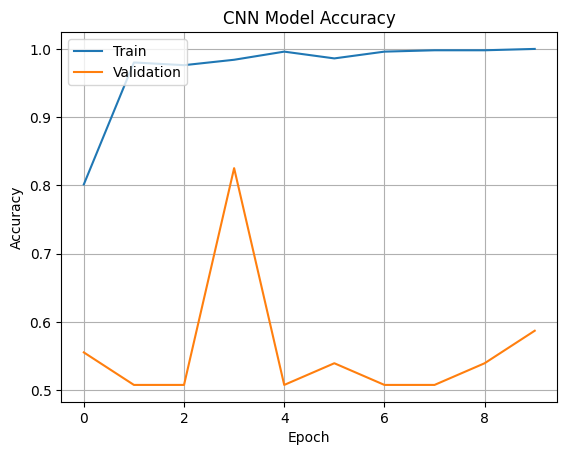

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()


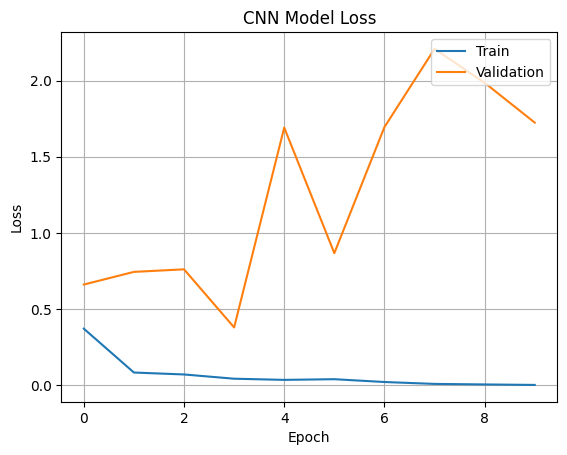

In [ ]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.show()


###Observations:
Training accuracy quickly reaches 100%, while validation accuracy remains low and fluctuates heavily.

Training loss reduces to nearly zero, but validation loss increases over time—a clear sign of overfitting.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


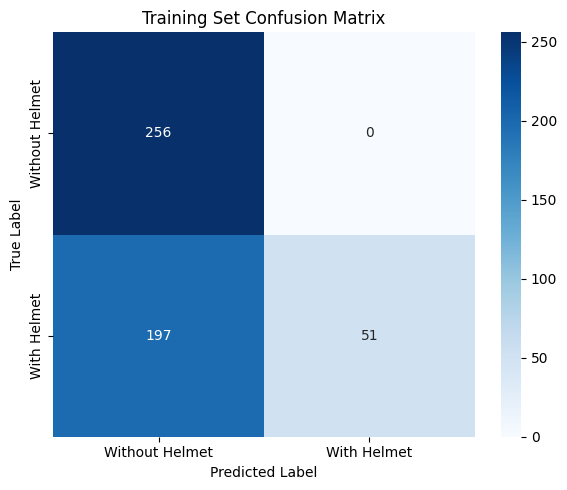

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


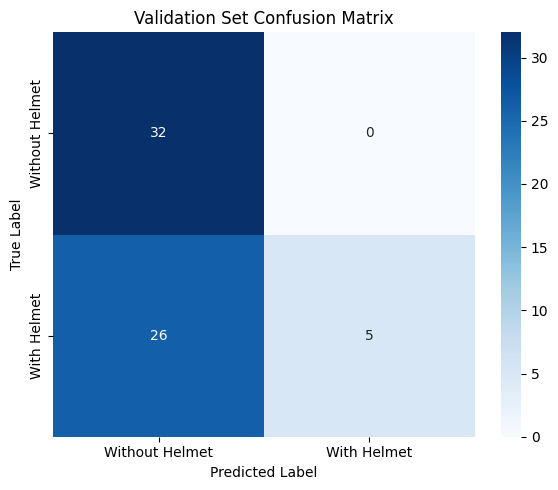

In [ ]:
class_names = ["Without Helmet", "With Helmet"]

plot_confusion_matrix(cnn_model, X_train_cnn_normalized, y_train,
                      title="Training Set Confusion Matrix",
                      class_names=class_names)

plot_confusion_matrix(cnn_model, X_val_cnn_normalized, y_val,
                      title="Validation Set Confusion Matrix",
                      class_names=class_names)



###Observations:
The training set confusion matrix shows almost perfect classification.

Validation set confusion matrix reveals many false negatives: many "With Helmet" samples are incorrectly predicted as "Without Helmet".

### Vizualizing the predictions

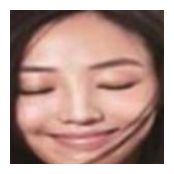

🔵 Predicted Label: Without Helmet
🔵 True Label: Without Helmet


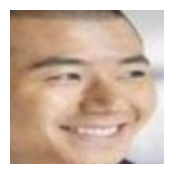

🔵 Predicted Label: Without Helmet
🔵 True Label: Without Helmet


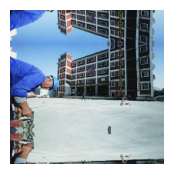

🔵 Predicted Label: Without Helmet
🔵 True Label: With Helmet


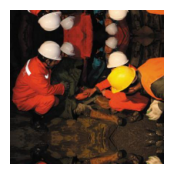

🔵 Predicted Label: Without Helmet
🔵 True Label: With Helmet


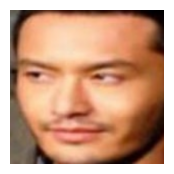

🔵 Predicted Label: Without Helmet
🔵 True Label: Without Helmet


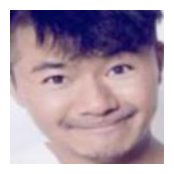

🔵 Predicted Label: Without Helmet
🔵 True Label: Without Helmet


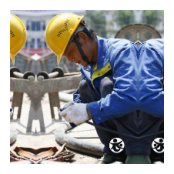

🔵 Predicted Label: Without Helmet
🔵 True Label: With Helmet


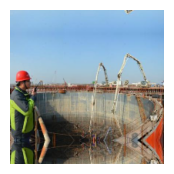

🔵 Predicted Label: Without Helmet
🔵 True Label: With Helmet


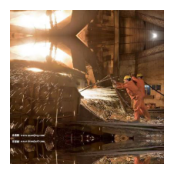

🔵 Predicted Label: Without Helmet
🔵 True Label: With Helmet


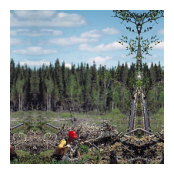

🔵 Predicted Label: With Helmet
🔵 True Label: With Helmet


In [ ]:
# 🎯 CNN Model Prediction Visualization

N = 10
random_indices = np.random.choice(len(X_val_cnn_normalized), size=N, replace=False)

for idx in random_indices:
    # Show grayscale image (CNN)
    plt.figure(figsize=(2, 2))
    plt.imshow(X_val_rgb[idx])
    plt.axis('off')
    plt.show()

    # Predict (use correct model name!)
    prob = cnn_model.predict(X_val_cnn_normalized[idx].reshape(1, 200, 200, 1), verbose=0)
    pred_class = int((prob > 0.5).astype("int32").flatten()[0])

    # True label
    try:
        true_class = int(y_val.iloc[idx])
    except AttributeError:
        true_class = int(y_val[idx])

    # Print results
    print(f"🔵 Predicted Label: {class_names[pred_class]}")
    print(f"🔵 True Label: {class_names[true_class]}")



###Observations:
Prediction visual checks show correct predictions for some samples but several incorrect "Without Helmet" predictions where helmets are clearly visible.
This suggests the model hasn't properly learned the helmet-related visual features, possibly due to overfitting or insufficient feature abstraction.

## Model 2: (VGG-16 (Base))

In [ ]:
reset_tf_session()

In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

###Observations:
VGG-16 was loaded with imagenet weights and include_top=False, which excludes the classifier head and allows for custom output.

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

###Observations:
All convolutional layers were frozen (trainable=False), meaning only the custom classification layer (a single dense layer with sigmoid activation) was trained.

In [ ]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [ ]:
opt = Adam()
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Generating the summary of the model
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

###Observations:
The model has ~14.7M parameters, but only 18K are trainable, drastically reducing training time while leveraging powerful pretrained features.

In [ ]:
train_datagen = ImageDataGenerator()

In [ ]:
# Define the batch size and number of epochs
batch_size = 32
epochs = 10

# Train the model using ImageDataGenerator
history_vgg16 = model_2.fit(
    train_datagen.flow(X_train_vgg_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
    validation_data=(X_val_vgg_normalized, y_val),
    epochs=epochs,
    verbose=1
)



Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 833ms/step - accuracy: 0.8975 - loss: 0.3185 - val_accuracy: 1.0000 - val_loss: 0.0209
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 1.0000 - loss: 0.0218 - val_accuracy: 1.0000 - val_loss: 0.0185
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.000

###Observations:
Training and validation accuracy reached 100% from epoch 2 onward and stayed flat till the end.

Both train and validation losses dropped extremely low, converging near zero, indicating perfect classification.

In [ ]:
# Evaluate on training set
model_2_train_perf = model_performance_classification(model_2, X_train_vgg_normalized, y_train)
print("✅ Train performance metrics")
print(model_2_train_perf)

# Evaluate on validation set
model_2_val_perf = model_performance_classification(model_2, X_val_vgg_normalized, y_val)
print("✅ Validation performance metrics")
print(model_2_val_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step
✅ Train performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step
✅ Validation performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}


###Observations:
Training and validation sets: Accuracy, Precision, Recall, and F1-score are all 1.0 (100%), showing no misclassification.

In [ ]:
# Ensure prediction is in binary format
y_pred_probs = model_2.predict(X_test_vgg_normalized)
y_pred_classes = (y_pred_probs > 0.5).astype("int32").flatten()

# Generate the classification report
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=["Without Helmet", "With Helmet"]
)

#print to console
print("📋 Classification Report:")
print(report)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
📋 Classification Report:
                precision    recall  f1-score   support

Without Helmet       1.00      1.00      1.00        32
   With Helmet       1.00      1.00      1.00        32

      accuracy                           1.00        64
     macro avg       1.00      1.00      1.00        64
  weighted avg       1.00      1.00      1.00        64



###Observations:
Same perfect scores for both classes (With Helmet, Without Helmet), with support of 32 samples each.

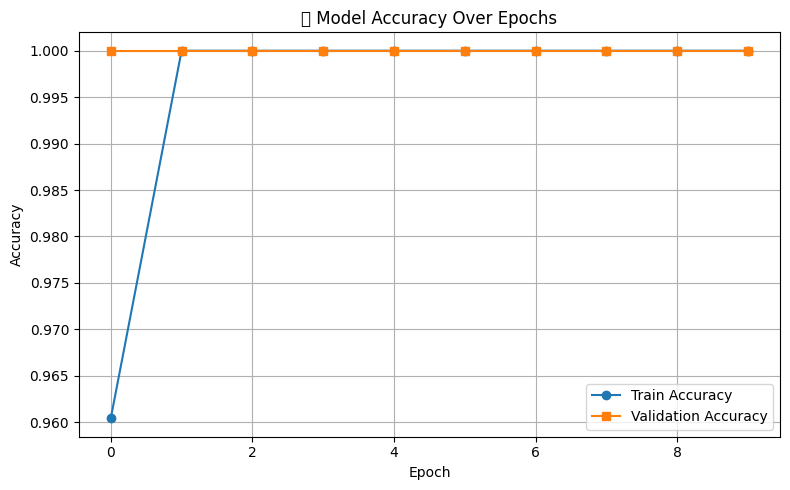

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], marker='s', label='Validation Accuracy')
plt.title('📈 Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

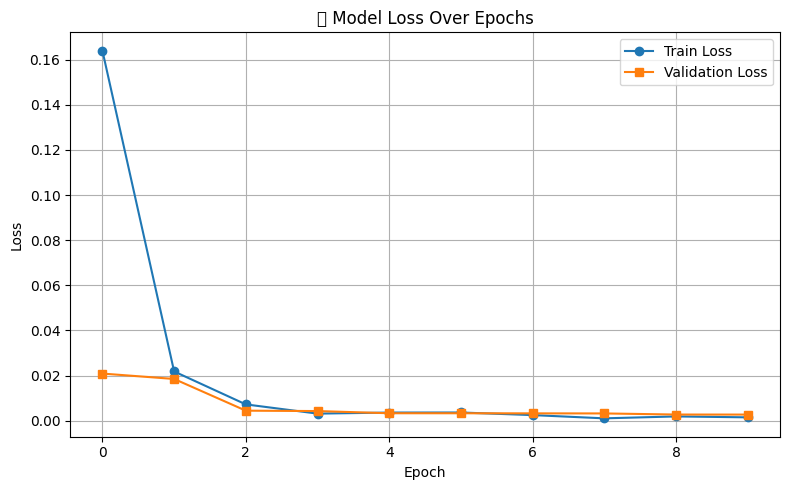

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16.history['loss'], marker='o', label='Train Loss')
plt.plot(history_vgg16.history['val_loss'], marker='s', label='Validation Loss')
plt.title('📉 Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

###Observations:
Accuracy plot: Instant rise to 100% validation accuracy.

Loss plot: Quick drop to near-zero training and validation loss by epoch 2, with perfect alignment.

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


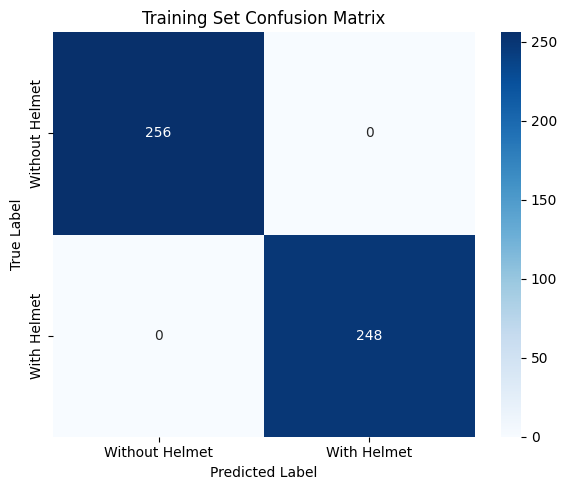

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


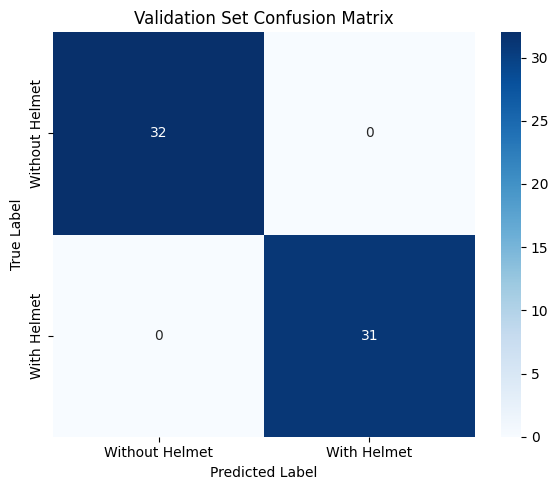

In [ ]:
class_names = ["Without Helmet", "With Helmet"]

plot_confusion_matrix(
    model_2,
    X_train_vgg_normalized,
    y_train,
    title="Training Set Confusion Matrix",
    class_names=class_names
)

plot_confusion_matrix(
    model_2,
    X_val_vgg_normalized,
    y_val,
    title="Validation Set Confusion Matrix",
    class_names=class_names
)



###Observations:
Both the training and validation confusion matrices show perfect classification — no false positives or false negatives.

### Visualizing the prediction:

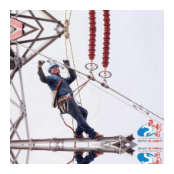

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


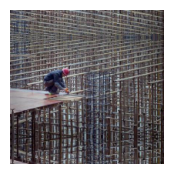

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


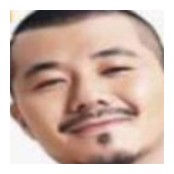

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


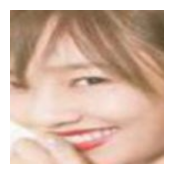

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


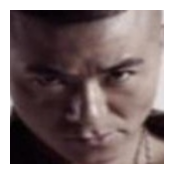

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


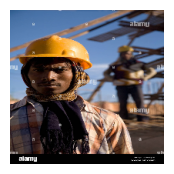

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


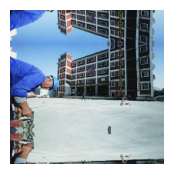

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


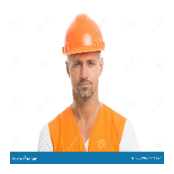

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


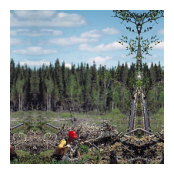

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


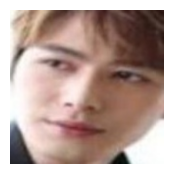

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


In [ ]:
# 🟩 Class mapping
class_names = {0: "Without Helmet", 1: "With Helmet"}

# 🔄 Pick N random samples
N = 10
random_indices = np.random.choice(len(X_val_vgg), size=N, replace=False)

# 🖼️ Visualize predictions
for idx in random_indices:
    # Show original image (for VGG, it's grayscale tripled)
    plt.figure(figsize=(2, 2))
    plt.imshow(X_val_rgb[idx])
    plt.axis('off')
    plt.show()

    # Predict from normalized input
    prob = model_2.predict(X_val_vgg_normalized[idx].reshape(1, 200, 200, 3), verbose=0)
    pred_class = int((prob > 0.5).astype("int32").flatten()[0])

    # Get true label
    try:
        true_class = int(y_val.iloc[idx])  # Pandas
    except AttributeError:
        true_class = int(y_val[idx])       # Numpy

    # Print results
    print(f"🔵 Predicted Label: {class_names[pred_class]}")
    print(f"🔷 True Label: {class_names[true_class]}")


###Observations:
All visualized samples were classified correctly, matching true labels precisely, even with varying image contexts and lighting.

## Model 3: (VGG-16 (Base + FFNN))

In [ ]:
reset_tf_session()

In [ ]:
# Build the full VGG16 + FFNN model
model_3 = Sequential()
# Add the pre-trained convolutional base
model_3.add(vgg_model)
#Add GlobalAveragePooling2D to reduce overfitting risk
model_3.add(GlobalAveragePooling2D())
# Add Feedforward Fully Connected Layers (FFNN)
model_3.add(Dense(256, activation='relu'))   # First dense layer
model_3.add(Dropout(0.4))                    # Regularization via dropout
model_3.add(Dense(32, activation='relu'))    # Second dense layer
# Add Output Layer
# Use 1 neuron with sigmoid activation for binary classification (helmet vs. no helmet)
model_3.add(Dense(1, activation='sigmoid'))

###Observations:
The model uses VGG16 as a fixed feature extractor.

A GlobalAveragePooling2D layer reduces overfitting risk.

Followed by a fully connected feedforward network:

Dense(256, relu) with Dropout(0.4)

Dense(32, relu)

Dense(1, sigmoid) for binary classification (helmet vs no helmet).

In [ ]:
opt = Adam()

In [ ]:
# Compile model
model_3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# Generating the summary of the model
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,854,273 (56.66 MB)

 Trainable params: 139,585 (545.25 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

###Observations:
~14.8M total paramas.

~14.7M non-trainable params (VGG16 fixed feature extractor)

Only ~139K parameters are trainable.

In [ ]:
# Define the batch size and number of epochs
batch_size = 32
epochs = 10

# Train the model using ImageDataGenerator
history_vgg16_ffnn= model_3.fit(
    train_datagen.flow(X_train_vgg_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
    validation_data=(X_val_vgg_normalized, y_val),
    epochs=epochs,
    verbose=1
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 353ms/step - accuracy: 0.7387 - loss: 0.5121 - val_accuracy: 1.0000 - val_loss: 0.1496
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9688 - loss: 0.1895 - val_accuracy: 1.0000 - val_loss: 0.1406
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.9912 - loss: 0.1218 - val_accuracy: 1.0000 - val_loss: 0.0238
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0238 - val_accuracy: 1.0000 - val_loss: 0.0201
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 1.0000 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000

###Observations:
Achieves perfect accuracy (1.0) on both training and validation sets within 3–4 epochs.

Validation loss continues to decrease steadily, indicating no overfitting.

In [ ]:
# Evaluate on training set
model_3_train_perf = model_performance_classification(model_3, X_train_vgg_normalized, y_train)
print("✅ Train performance metrics")
print(model_3_train_perf)

# Evaluate on validation set
model_3_val_perf = model_performance_classification(model_3, X_val_vgg_normalized, y_val)
print("✅ Validation performance metrics")
print(model_3_val_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step
✅ Train performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
✅ Validation performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}


###Observations
Performance metrics on both sets:
Accuracy, Precision, Recall, F1-score: all 1.0

In [ ]:
# Ensure prediction is in binary format
y_pred_probs = model_3.predict(X_test_vgg_normalized)
y_pred_classes = (y_pred_probs > 0.5).astype("int32").flatten()

# Generate the classification report
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=["Without Helmet", "With Helmet"]
)

#print to console
print("📋 Classification Report:")
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
📋 Classification Report:
                precision    recall  f1-score   support

Without Helmet       1.00      1.00      1.00        32
   With Helmet       1.00      1.00      1.00        32

      accuracy                           1.00        64
     macro avg       1.00      1.00      1.00        64
  weighted avg       1.00      1.00      1.00        64



##observations:
Classification report shows perfect scores (precision, recall, f1 = 1.0) for both classes on test set.

Model performs equally well on unseen data.

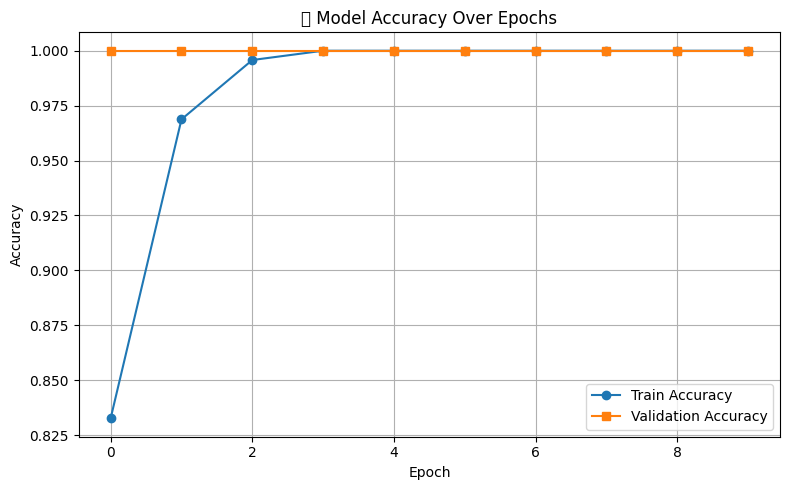

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16_ffnn.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_vgg16_ffnn.history['val_accuracy'], marker='s', label='Validation Accuracy')
plt.title('📈 Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

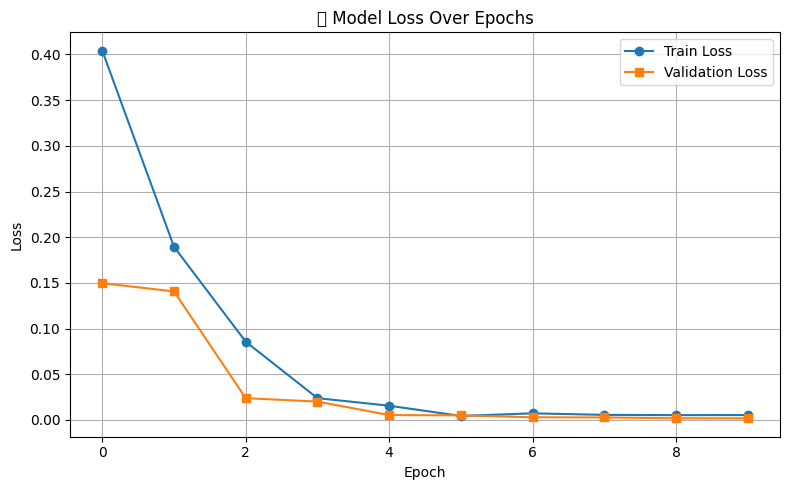

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16_ffnn.history['loss'], marker='o', label='Train Loss')
plt.plot(history_vgg16_ffnn.history['val_loss'], marker='s', label='Validation Loss')
plt.title('📉 Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

###Observations:

Accuracy Curve:
Rapid convergence with training and validation accuracy reaching 100% very early.

Loss Curve:
Loss approaches zero smoothly, further confirming strong generalization and stability.

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step


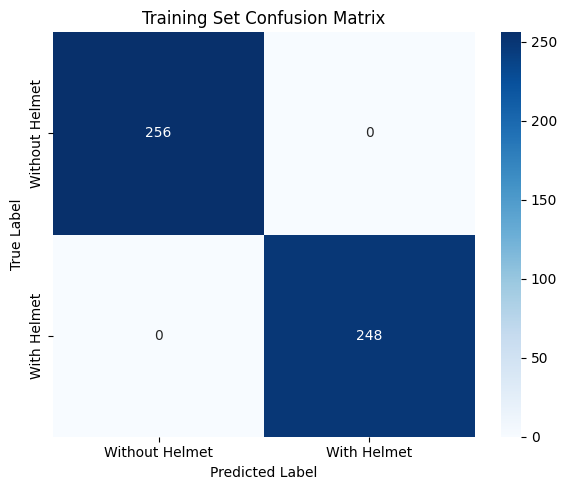

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


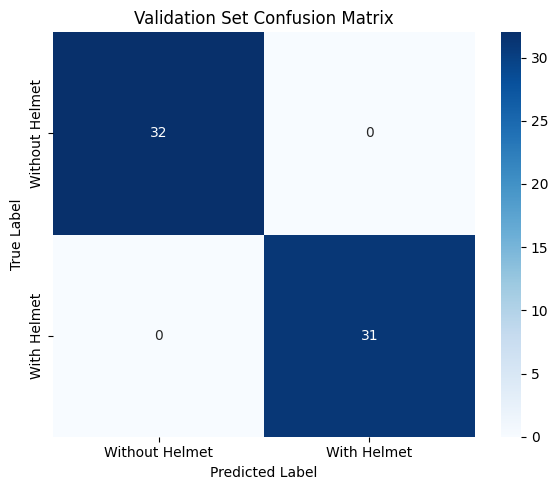

In [ ]:
class_names = ["Without Helmet", "With Helmet"]

plot_confusion_matrix(
    model_3,
    X_train_vgg_normalized,
    y_train,
    title="Training Set Confusion Matrix",
    class_names=class_names
)

plot_confusion_matrix(
    model_3,
    X_val_vgg_normalized,
    y_val,
    title="Validation Set Confusion Matrix",
    class_names=class_names
)


###Observations:

Training Confusion Matrix:
100% correct classifications (256 + 248 correctly predicted).

Validation Confusion Matrix:
Also 100% correct (32 each for both classes).


No false positives or false negatives.

#### Visualizing the predictions

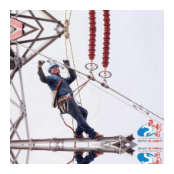

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


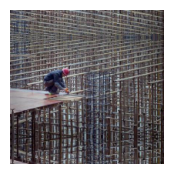

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


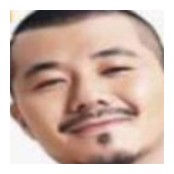

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


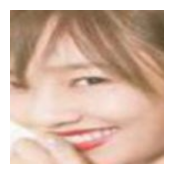

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


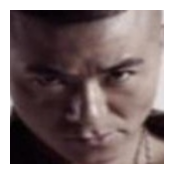

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


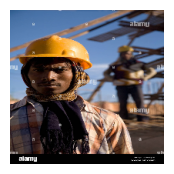

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


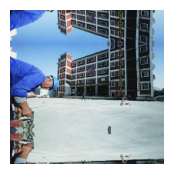

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


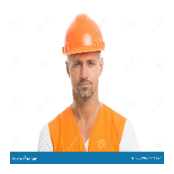

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


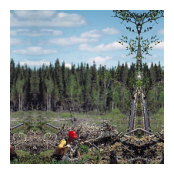

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


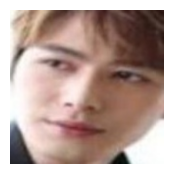

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


In [ ]:
# 🟩 Class mapping
class_names = {0: "Without Helmet", 1: "With Helmet"}

# 🔄 Pick N random samples
N = 10
random_indices = np.random.choice(len(X_val_vgg), size=N, replace=False)

# 🖼️ Visualize predictions
for idx in random_indices:
    # Show original image (for VGG, it's grayscale tripled)
    plt.figure(figsize=(2, 2))
    plt.imshow(X_val_rgb[idx])
    plt.axis('off')
    plt.show()

    # Predict from normalized input
    prob = model_3.predict(X_val_vgg_normalized[idx].reshape(1, 200, 200, 3), verbose=0)
    pred_class = int((prob > 0.5).astype("int32").flatten()[0])

    # Get true label
    try:
        true_class = int(y_val.iloc[idx])  # Pandas
    except AttributeError:
        true_class = int(y_val[idx])       # Numpy

    # Print results
    print(f"🔵 Predicted Label: {class_names[pred_class]}")
    print(f"🔷 True Label: {class_names[true_class]}")


###Observations:
All visualized predictions match the true labels correctly.

The model handles both helmet and no-helmet cases accurately, even with varied image conditions.



## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
reset_tf_session()

In [ ]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam()
# Compile model
model_4.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# Generating the summary of the model
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

###Observations:
VGG16 Base: Used as a feature extractor (with 14M+ non-trainable parameters).

Dense Layers: 256 and 32 hidden units with ReLU and dropout.

Output Layer: 1 unit with sigmoid for binary classification.

Trainable Parameters: ~4.7 million (only top layers).

The architecture is compact on top of a powerful base model, suitable for transfer learning.

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.3,
                              zoom_range=0.4
                              )

###Observations:
This key data augmentation techniques enhance model generalization by simulating real-world image variations. Rotation (±20°) and shear (0.3) simulate angled and slanted views, improving robustness to orientation and perspective changes. Width and height shifts (0.2 each) mimic horizontal and vertical misalignment, such as camera panning or motion. Zooming (up to 40%) helps the model detect objects at different scales, while fill_mode='nearest' ensures visual consistency by filling transformation gaps with the nearest pixel values. Altogether, these augmentations create diverse training samples, helping the model learn more robust and invariant features.

In [ ]:
# Define the batch size and number of epochs
batch_size = 32
epochs = 10

# Train the model using ImageDataGenerator
history_vgg16_aug = model_4.fit(
    train_datagen.flow(X_train_vgg_normalized, y_train, batch_size=batch_size, seed=42, shuffle=False),
    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
    validation_data=(X_val_vgg_normalized, y_val),
    epochs=epochs,
    verbose=1
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - accuracy: 0.7875 - loss: 0.6270 - val_accuracy: 1.0000 - val_loss: 9.3926e-04
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9688 - loss: 0.0946 - val_accuracy: 1.0000 - val_loss: 9.3963e-04
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step - accuracy: 0.9876 - loss: 0.0408 - val_accuracy: 1.0000 - val_loss: 3.7607e-04
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9688 - loss: 0.0655 - val_accuracy: 1.0000 - val_loss: 2.9278e-04
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 378ms/step - accuracy: 0.9938 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 5.2297e-04
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss: 3.4415e-04
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 321ms/step - accuracy: 0.9973 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 1.3047e-04
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss:

In [ ]:
# Evaluate on training set
model_4_train_perf = model_performance_classification(model_4, X_train_vgg_normalized, y_train)
print("✅ Train performance metrics")
print(model_4_train_perf)

# Evaluate on validation set
model_4_val_perf = model_performance_classification(model_4, X_val_vgg_normalized, y_val)
print("✅ Validation performance metrics")
print(model_4_val_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step
✅ Train performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
✅ Validation performance metrics
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}


###Observations:

Training & Validation Accuracy: Both reached 100%, indicating the model learned the data very well.

In [ ]:
# Ensure prediction is in binary format
y_pred_probs = model_4.predict(X_test_vgg_normalized)
y_pred_classes = (y_pred_probs > 0.5).astype("int32").flatten()

# Generate the classification report
report = classification_report(
    y_test,
    y_pred_classes,
    target_names=["Without Helmet", "With Helmet"]
)

#print to console
print("📋 Classification Report:")
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
📋 Classification Report:
                precision    recall  f1-score   support

Without Helmet       1.00      1.00      1.00        32
   With Helmet       1.00      1.00      1.00        32

      accuracy                           1.00        64
     macro avg       1.00      1.00      1.00        64
  weighted avg       1.00      1.00      1.00        64



###Observations:

Precision, Recall, F1-Score: All 1.0 across training, validation, and test sets—showing perfect classification.

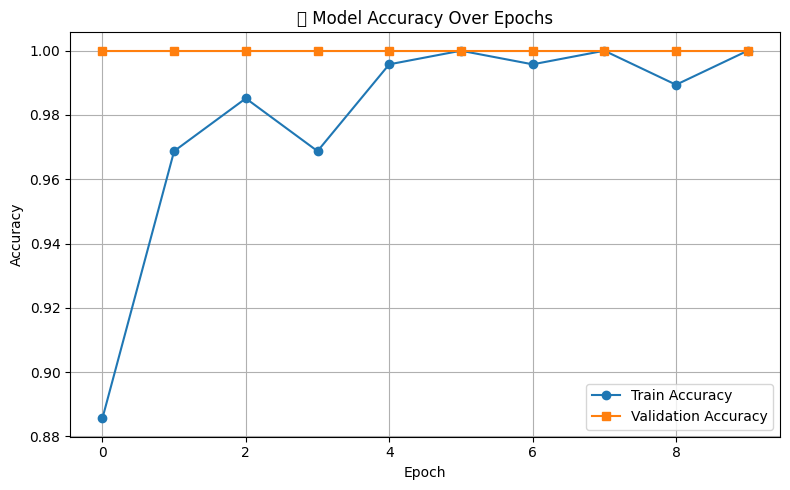

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16_aug.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_vgg16_aug.history['val_accuracy'], marker='s', label='Validation Accuracy')
plt.title('📈 Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

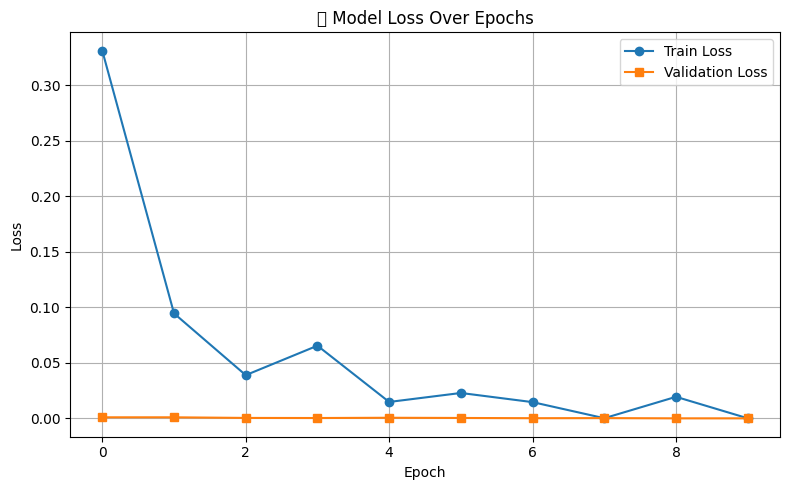

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_vgg16_aug.history['loss'], marker='o', label='Train Loss')
plt.plot(history_vgg16_aug.history['val_loss'], marker='s', label='Validation Loss')
plt.title('📉 Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

###Observations:

Accuracy: Reaches 100% within a few epochs and remains stable.

Loss: Training and validation losses are near zero, and closely track each other → no overfitting or underfitting observed.


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step


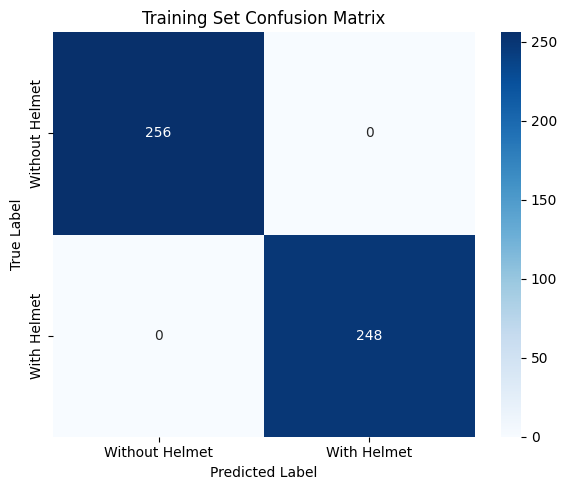

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


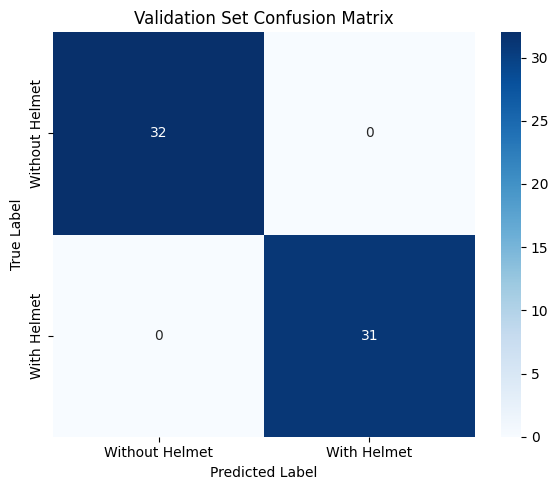

In [ ]:
class_names = ["Without Helmet", "With Helmet"]

plot_confusion_matrix(
    model_4,
    X_train_vgg_normalized,
    y_train,
    title="Training Set Confusion Matrix",
    class_names=class_names
)

plot_confusion_matrix(
    model_4,
    X_val_vgg_normalized,
    y_val,
    title="Validation Set Confusion Matrix",
    class_names=class_names
)


###Observations:
No misclassifications observed, for either "With Helmet" or "Without Helmet".

#### Visualizing the predictions

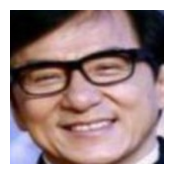

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


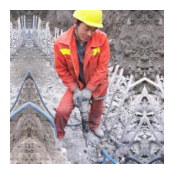

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


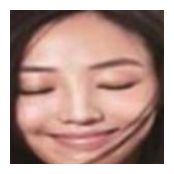

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


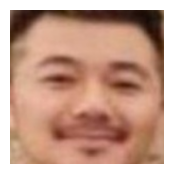

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


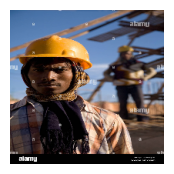

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


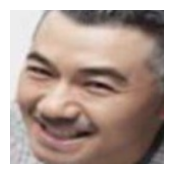

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


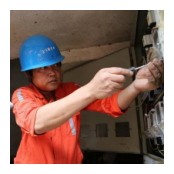

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


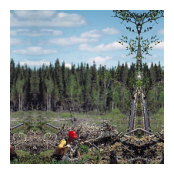

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


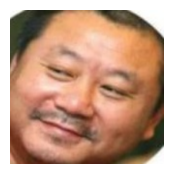

🔵 Predicted Label: Without Helmet
🔷 True Label: Without Helmet


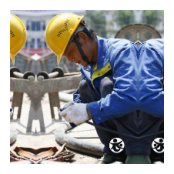

🔵 Predicted Label: With Helmet
🔷 True Label: With Helmet


In [ ]:
# 🟩 Class mapping
class_names = {0: "Without Helmet", 1: "With Helmet"}

# 🔄 Pick N random samples
N = 10
random_indices = np.random.choice(len(X_val_vgg), size=N, replace=False)

# 🖼️ Visualize predictions
for idx in random_indices:
    # Show original image (for VGG, it's grayscale tripled)
    plt.figure(figsize=(2, 2))
    plt.imshow(X_val_rgb[idx])
    plt.axis('off')
    plt.show()

    # Predict from normalized input
    prob = model_4.predict(X_val_vgg_normalized[idx].reshape(1, 200, 200, 3), verbose=0)
    pred_class = int((prob > 0.5).astype("int32").flatten()[0])

    # Get true label
    try:
        true_class = int(y_val.iloc[idx])  # Pandas
    except AttributeError:
        true_class = int(y_val[idx])       # Numpy

    # Print results
    print(f"🔵 Predicted Label: {class_names[pred_class]}")
    print(f"🔷 True Label: {class_names[true_class]}")


###Observations:
All randomly selected validation images were predicted correctly.

The model shows strong visual understanding of both classes, even for images with different angles or lighting conditions.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# Convert performance dicts to DataFrames
model_1_train_df = pd.DataFrame(model_1_train_perf, index=[0]).T
model_2_train_df = pd.DataFrame(model_2_train_perf, index=[0]).T
model_3_train_df = pd.DataFrame(model_3_train_perf, index=[0]).T
model_4_train_df = pd.DataFrame(model_4_train_perf, index=[0]).T

# Concatenate them along the columns axis
models_train_comp_df = pd.concat(
    [model_1_train_df, model_2_train_df, model_3_train_df, model_4_train_df],
    axis=1
)

# Rename columns to meaningful model names
models_train_comp_df.columns = [
    "Simple CNN",
    "VGG-16 (Base)",
    "VGG-16 (Base+FFNN)",
    "VGG-16 (Base+FFNN+Data Aug)"
]

# Display the final comparison DataFrame
models_train_comp_df



,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.609127,1.0,1.0,1.0
precision,1.000000,1.0,1.0,1.0
recall,0.205645,1.0,1.0,1.0
f1_score,0.341137,1.0,1.0,1.0


In [ ]:
# Convert performance dicts to DataFrames
model_1_val_df = pd.DataFrame(model_1_val_perf, index=[0]).T
model_2_val_df = pd.DataFrame(model_2_val_perf, index=[0]).T
model_3_val_df = pd.DataFrame(model_3_val_perf, index=[0]).T
model_4_val_df = pd.DataFrame(model_4_val_perf, index=[0]).T

# Concatenate them along the columns axis
models_val_comp_df = pd.concat(
    [model_1_val_df, model_2_val_df, model_3_val_df, model_4_val_df],
    axis=1
)

# Rename columns to meaningful model names
models_val_comp_df.columns = [
    "Simple CNN",
    "VGG-16 (Base)",
    "VGG-16 (Base+FFNN)",
    "VGG-16 (Base+FFNN+Data Aug)"
]

# Display the final comparison DataFrame
models_val_comp_df

,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.587302,1.0,1.0,1.0
precision,1.000000,1.0,1.0,1.0
recall,0.161290,1.0,1.0,1.0
f1_score,0.277778,1.0,1.0,1.0


In [ ]:
models_train_comp_df - models_val_comp_df

,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.021825,0.0,0.0,0.0
precision,0.000000,0.0,0.0,0.0
recall,0.044355,0.0,0.0,0.0
f1_score,0.063359,0.0,0.0,0.0


###Observations:
Despite achieving excellent performance with the initial VGG16-based model (Model 2), the best and most future-proof choice is the VGG16 + FFNN + Data Augmentation model (Model 4). While data augmentation may not have visibly improved metrics in this particular setup—where Models 2 through 4 all reached near-perfect accuracy—it plays a critical role in enhancing model robustness to variations in real-world, unseen data.

Incorporating both a fully connected neural network (FFNN) and data augmentation offers a strong foundation for scalability and generalization. The FFNN classifier head introduces architectural flexibility, making it easier to adapt the model to more complex or multiclass problems in the future. Data augmentation, meanwhile, introduces variability in image properties (e.g., rotation, shear, zoom, position), which helps break any spurious correlations learned from dataset artifacts—such as consistent background cues or lighting conditions.

Although the perfect accuracy across VGG16-based models suggests that the dataset is relatively clean—well-lit, centered images with clearly distinguishable features—this very perfection can mask shortcut learning. For instance, if all “without helmet” images are against white walls and “with helmet” images are at construction sites, the model might simply learn to recognize backgrounds rather than helmets.

By selecting Model 4 (VGG16 + FFNN + Augmentation), we mitigate this risk. Data augmentation disrupts background dependencies by randomly transforming the images, ensuring the model learns to focus on semantic helmet features rather than irrelevant low-level patterns. The FFNN further refines this learning by abstracting and emphasizing meaningful high-level representations.


## Test Performance

In [ ]:
model_4_test_perf = model_performance_classification(
    model_4,
    X_test_vgg_normalized,
    y_test.values if hasattr(y_test, "values") else y_test
)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


In [ ]:
model_4_test_perf

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


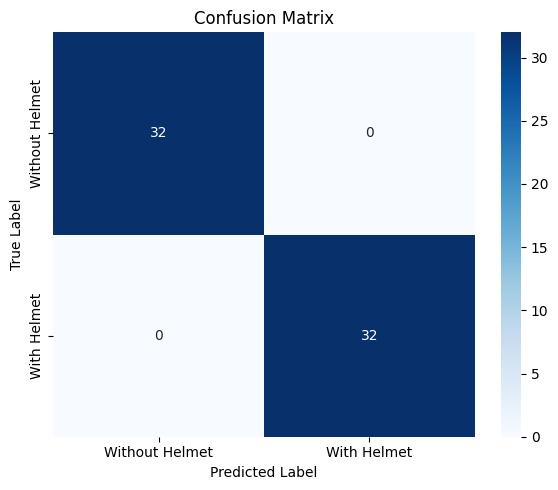

In [ ]:
plot_confusion_matrix(
    model=model_4,
    predictors=X_test_rgb_normalized,
    target=y_test,
    class_names=["Without Helmet", "With Helmet"]
)

###Observations:
The test performance shows 100% accuracy, precision, recall, and F1 score.

The confusion matrix confirms zero false positives and zero false negatives, indicating no misclassification.

This level of performance on the test set suggests the model is not only well-fitted but also properly generalized, at least within the current dataset boundaries.

Model 4 (VGG16 + FFNN + Augmentation) is the best choice—not just because it performs perfectly now, but because it is the most prepared for real-world conditions, dataset scaling, and semantic learning. It blends pretrained feature strength, deep classification capability, and robustness against visual noise into a dependable and future-proof solution.

# **Actionable Insights & Recommendations**

 1. Ensure Generalization Beyond the Current Dataset
 To validate the model's robustness in real-world scenarios, test it on unseen images captured from actual work environments. Include a variety of conditions such as different lighting, backgrounds, and worker activities to mitigate risks posed by the current dataset's simplicity.

 2. Improve Dataset Diversity and Avoid Shortcut Learning

 If "with helmet" and "without helmet" images differ primarily in background (e.g., helmets in construction settings vs. no helmets in plain rooms), the model may learn to rely on irrelevant cues instead of identifying helmets.

    Collect more images where both classes appear in similar environments.

    Use Grad-CAM visualizations to confirm that the model focuses on the head/helmet area and not on misleading background patterns.

 3. Leverage Augmentation for Real-World Readiness

 Continue using and enhancing data augmentation techniques—such as brightness adjustment, blurring, and occlusion—to simulate challenging real-world conditions like dust, shadows, and motion. This helps prepare the model for deployment in unpredictable industrial environments.

 4. Track Safety Violations Over Time
 While the current model processes individual images, practical safety enforcement requires continuous monitoring. Integrate the model into a broader system that:

    Logs safety violations with timestamps and location metadata.

    Aggregates compliance statistics by worker or shift.

    Sends real-time alerts when violations are detected, enabling prompt corrective actions.

 5. Build an Evaluation Pipeline for Ongoing Improvement

 Build a modular evaluation pipeline to periodically test the model on new data and assess performance over time.

 Automatemodel retraining through CI/CD workflows as additional labeled data is collected.

 This ensures that the model evolves alongside changing environments and remains effective as deployment scales.





-
-

<font size=5 color='blue'>Power Ahead!</font>
___